# LaMa Inpaint — Occlusion Removal

**Muc dich**: Dung LaMa de inpaint vung overlap giua 2 vat the.

**Pipeline**:
1. Tai anh goc + mask A (occluder) + mask B (target)
2. Seed mau tu ria B vao overlap (median color)
3. LaMa inpaint vung overlap
4. Dung `refine_background` co san trong helpers.py de snap mau
5. Hien thi ket qua


## 1. Import & Cau hinh


In [1]:
import os, sys
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# === Cau hinh ===
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

IMAGE_PATH = PROJECT_ROOT / "sam3" / "assets" / "images" / "composite.png"
MASK_A_PATH = PROJECT_ROOT / "sam3" / "masks" / "raw_mask_4.png"   # occluder
MASK_B_PATH = PROJECT_ROOT / "sam3" / "09_amodal_mask_sample1_original_size.png"  # target

DEVICE = "cuda"
print(f"Device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")


Device: cuda
Project root: /home/intern


## 2. Tai anh & mask


In [2]:
# Tai anh
image = Image.open(IMAGE_PATH).convert("RGB")
img_np = np.array(image, dtype=np.uint8)
orig_w, orig_h = image.size

# Tai mask
mask_A = np.array(Image.open(MASK_A_PATH).convert("L").resize((orig_w, orig_h), Image.NEAREST)) > 128
mask_B = np.array(Image.open(MASK_B_PATH).convert("L").resize((orig_w, orig_h), Image.NEAREST)) > 128

overlap = mask_A & mask_B
print(f"Image: {orig_w}x{orig_h}")
print(f"A (occluder): {mask_A.sum()} px")
print(f"B (target):   {mask_B.sum()} px")
print(f"Overlap:      {overlap.sum()} px")


Image: 6614x4252
A (occluder): 1382887 px
B (target):   1230104 px
Overlap:      180526 px


## 3. Hien thi dau vao


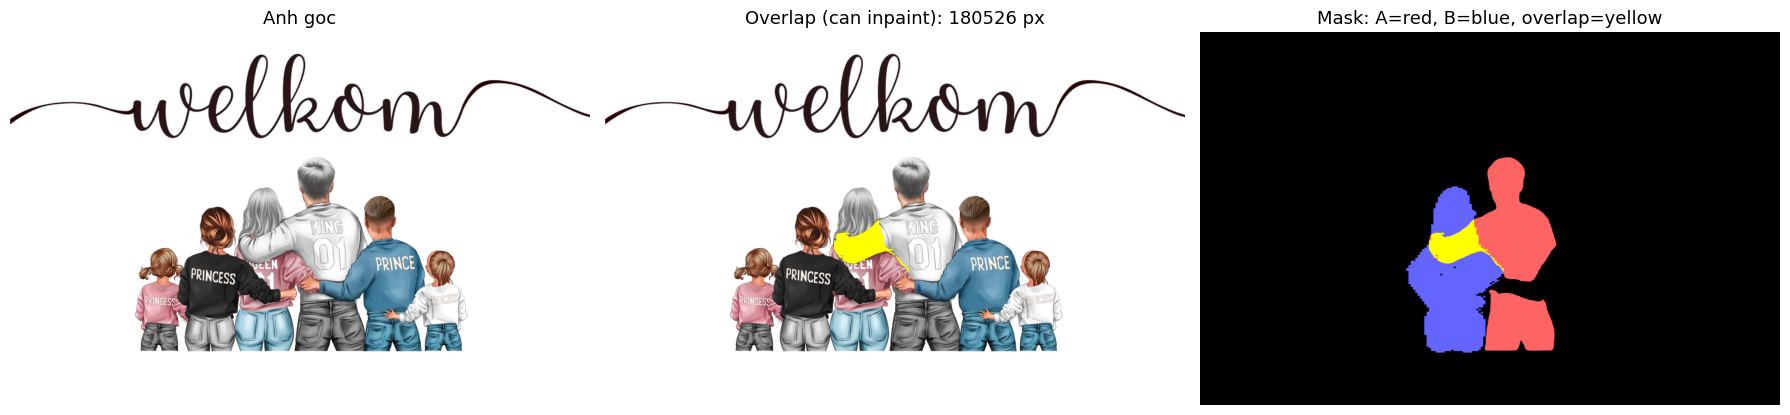

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Anh goc", fontsize=13)
axes[0].axis("off")

# Overlay overlap
overlay = img_np.copy()
overlay[overlap] = [255, 255, 0]  # yellow
axes[1].imshow(overlay)
axes[1].set_title(f"Overlap (can inpaint): {overlap.sum()} px", fontsize=13)
axes[1].axis("off")

# Mask visualization
mask_vis = np.zeros((*mask_A.shape, 3), dtype=np.uint8)
mask_vis[mask_A] = [255, 100, 100]  # red = A
mask_vis[mask_B] = [100, 100, 255]  # blue = B
mask_vis[overlap] = [255, 255, 0]   # yellow = overlap
axes[2].imshow(mask_vis)
axes[2].set_title("Mask: A=red, B=blue, overlap=yellow", fontsize=13)
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 4. Inpaint overlap bang LaMa


In [5]:
from simple_lama_inpainting import SimpleLama

# Import helpers co san
ROOT = Path.cwd()
if ROOT.name == 'examples':
    ROOT = ROOT.parent

# Add backend to path so relative imports in image_processor work
backend_path = ROOT / 'backend'
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))
sys.path.insert(0, str(ROOT))

from backend.helpers import expand_mask, refine_background

print("Loading LaMa...")
lama = SimpleLama(device=DEVICE)
print("LaMa ready.")

# ── Buoc 1: Seed mau tu ria B vao overlap ──
overlap = mask_A & mask_B
visible_B = mask_B & ~overlap

if visible_B.sum() > 0:
    # Lay median color cua B o vung visible sat overlap
    B_median = np.median(img_np[visible_B], axis=0).astype(np.uint8)
    print(f"B median color: {B_median}")
else:
    B_median = np.median(img_np[mask_B], axis=0).astype(np.uint8)
    print(f"B median color (full): {B_median}")

# Seed vao overlap
seeded = img_np.copy()
seeded[overlap] = B_median

# ── Buoc 2: Inpaint mask = overlap mo rong ──
kernel_size = (max(3, int(orig_h * 0.015)), max(3, int(orig_w * 0.015)))
inpaint_mask = expand_mask(overlap, kernel_size)
print(f"Inpaint mask: {inpaint_mask.sum()} px (expanded from {overlap.sum()} px)")

# ── Buoc 3: LaMa inpaint ──
mask_pil = Image.fromarray(inpaint_mask.astype(np.uint8) * 255).convert("L")
result = lama(Image.fromarray(seeded), mask_pil)
if result.size != (orig_w, orig_h):
    result = result.resize((orig_w, orig_h), Image.LANCZOS)
result_np = np.array(result.convert("RGB"), dtype=np.uint8)

# ── Buoc 4: Refine background (dung helpers co san) ──
refined = refine_background(
    result_np,
    inpaint_mask.astype(bool),
    n_outer_ratio=0.2,
    max_num_colors=10,
)

print("Done!")


Loading LaMa...
LaMa ready.
B median color: [158 147 154]
Inpaint mask: 319496 px (expanded from 180526 px)
Done!


## 5. Hien thi ket qua


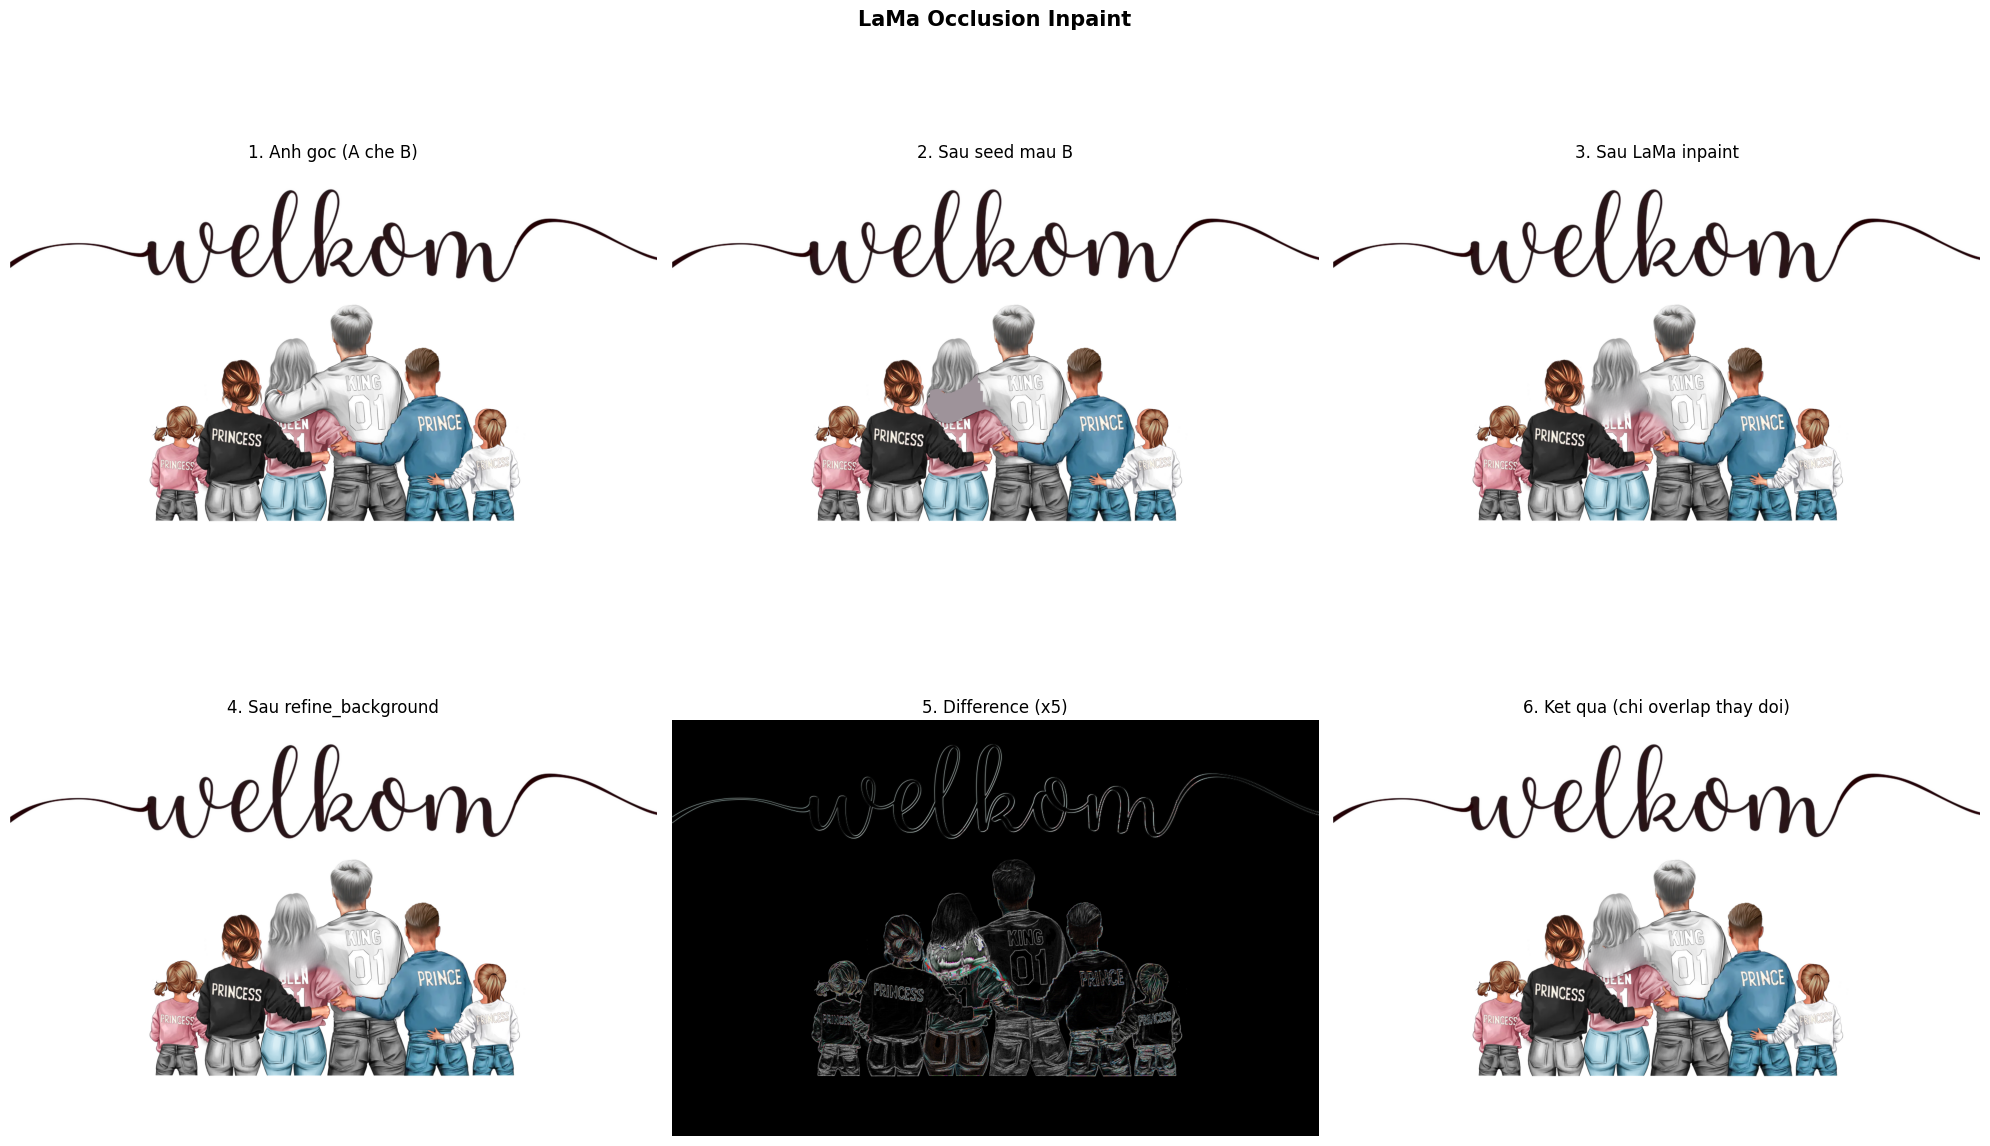

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

axes[0, 0].imshow(image)
axes[0, 0].set_title("1. Anh goc (A che B)", fontsize=12)
axes[0, 0].axis("off")

axes[0, 1].imshow(seeded)
axes[0, 1].set_title("2. Sau seed mau B", fontsize=12)
axes[0, 1].axis("off")

axes[0, 2].imshow(result_np)
axes[0, 2].set_title("3. Sau LaMa inpaint", fontsize=12)
axes[0, 2].axis("off")

axes[1, 0].imshow(refined)
axes[1, 0].set_title("4. Sau refine_background", fontsize=12)
axes[1, 0].axis("off")

# Difference map
diff = np.abs(refined.astype(int) - img_np.astype(int)).astype(np.uint8)
axes[1, 1].imshow(diff * 5)  # x5 de de thay
axes[1, 1].set_title("5. Difference (x5)", fontsize=12)
axes[1, 1].axis("off")

# Chi vung overlap
overlap_crop = refined.copy()
overlap_crop[~overlap] = img_np[~overlap]
axes[1, 2].imshow(overlap_crop)
axes[1, 2].set_title("6. Ket qua (chi overlap thay doi)", fontsize=12)
axes[1, 2].axis("off")

plt.suptitle("LaMa Occlusion Inpaint", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. So sanh truoc/sau tai vung overlap


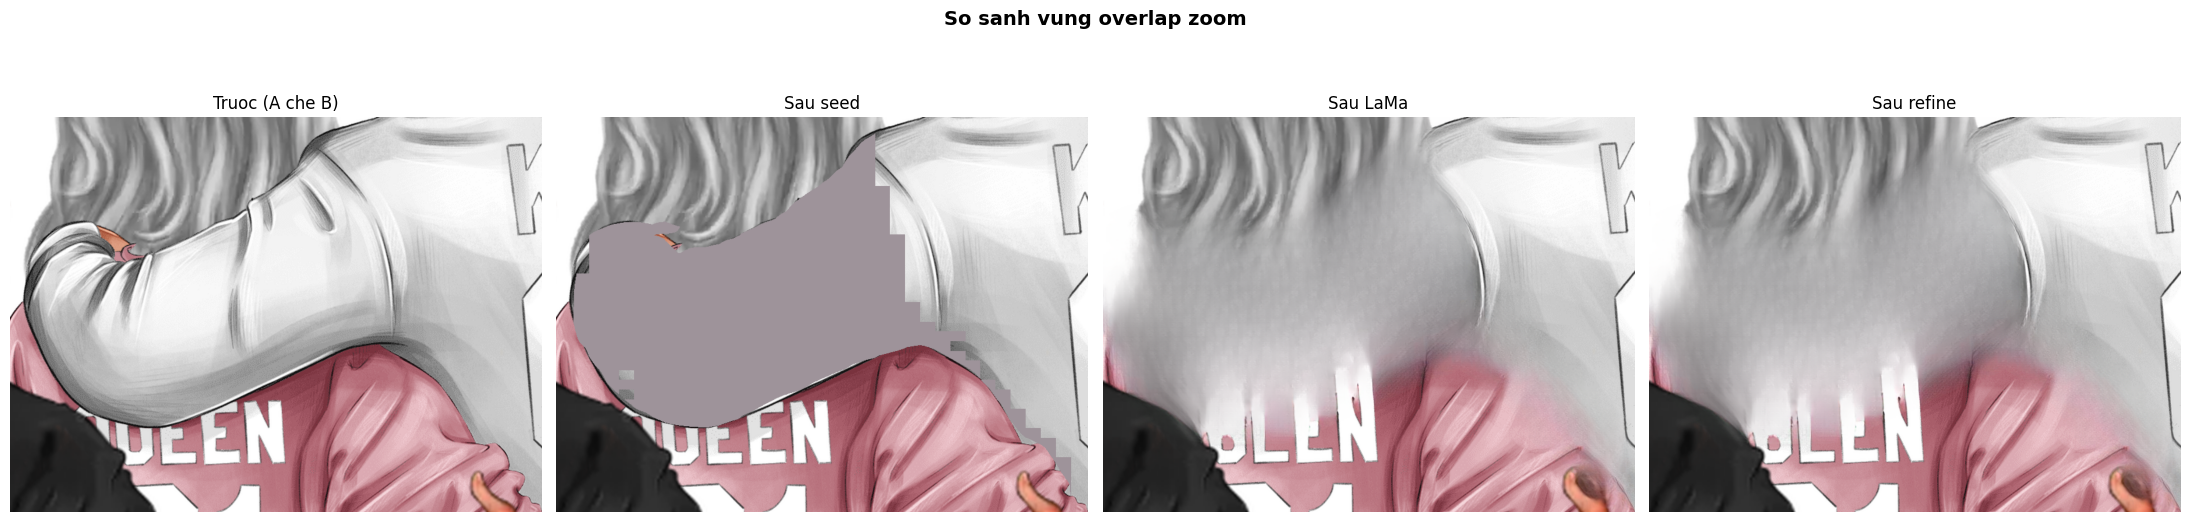

In [7]:
# Crop vung overlap + padding
rows = np.any(overlap, axis=1)
cols = np.any(overlap, axis=0)
y0, y1 = np.where(rows)[0][[0, -1]]
x0, x1 = np.where(cols)[0][[0, -1]]
pad = 30
y0c, y1c = max(0, y0-pad), min(orig_h, y1+pad)
x0c, x1c = max(0, x0-pad), min(orig_w, x1+pad)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(img_np[y0c:y1c, x0c:x1c])
axes[0].set_title("Truoc (A che B)", fontsize=12)
axes[0].axis("off")

axes[1].imshow(seeded[y0c:y1c, x0c:x1c])
axes[1].set_title("Sau seed", fontsize=12)
axes[1].axis("off")

axes[2].imshow(result_np[y0c:y1c, x0c:x1c])
axes[2].set_title("Sau LaMa", fontsize=12)
axes[2].axis("off")

axes[3].imshow(refined[y0c:y1c, x0c:x1c])
axes[3].set_title("Sau refine", fontsize=12)
axes[3].axis("off")

plt.suptitle("So sanh vung overlap zoom", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Luu ket qua


In [ ]:
refined_pil = Image.fromarray(refined)
refined_pil.save("inpaint_result.png")
print(f"Da luu: {os.path.abspath('inpaint_result.png')}")
